# ĐỒ ÁN: TIỀN XỬ LÍ DỮ LIỆU
1. Task 1: Loại bỏ các cột mà nhóm nghĩ là không cần thiết:

Ở phần EDA, chúng ta đã phát hiện được cột 'sync_error_message' và cột 'is_deleted' có chứa ít thông tin, cụ thể:
+ Tất cả giá trị ở cột 'sync_error_message' đều mang giá trị 'None'.
+ Tất cả giá trị ở cột 'is_deleted' đều mang giá trị 'False'.

Nên 2 cột này không mang lại giá trị thông tin gì cho quá trình phân tích và huấn luyện mô hình (không giúp phân biệt hay giải thích sự khác biệt giữa các mẫu dữ liệu, nếu giữ lại sẽ làm tăng độ nhiễu cũng như kích thước dữ liệu không cần thiết).

Vì vậy, nhóm quyết định loại bỏ 2 cột này nhằm:
+ Giảm độ phức tạp của tập dữ liệu.
+ Tiết kiệm tài nguyên xử lí.
+ Tránh để mô hình học máy bị ảnh hưởng bởi các đặc trưng không có ý nghĩa.

 

In [1]:
import polars as pl
import glob

# Load Items data
items_df = pl.read_parquet('sales_pers.item_chunk_0.parquet')
print(f' Items: {items_df.shape[0]:,} rows × {items_df.shape[1]} columns')

# Load Users data
user_files = sorted(glob.glob('sales_pers.user_chunk_*.parquet'))
users_df = pl.read_parquet(user_files)
print(f' Users: {users_df.shape[0]:,} rows × {users_df.shape[1]} columns')

# Load Purchase History data
purchase_pattern = 'sales_pers.purchase_history_daily_chunk_*.parquet'

# Sử dụng scan_parquet cho lazy evaluation (tối ưu nhất)
purchases_df = pl.scan_parquet(purchase_pattern).collect()
print(f' Purchases: {purchases_df.shape[0]:,} rows × {purchases_df.shape[1]} columns')


 Items: 27,332 rows × 34 columns
 Users: 4,573,964 rows × 18 columns
 Purchases: 35,729,825 rows × 16 columns


In [2]:
# XÓA CÁC CỘT ÍT THÔNG TIN: 'sync_error_message' & 'is_deleted'
cols_to_drop = ['sync_error_message', 'is_deleted']

def safe_drop(df, cols):
    # Lọc ra những cột thực sự tồn tại trong dataframe
    existing = [c for c in cols if c in df.columns]
    if existing:
        df = df.drop(existing)
        print(f"  Đã xóa các cột: {existing}")
    else:
        print("  Không có cột nào trong danh sách cần xóa tồn tại.")
    return df

In [3]:
items_df = safe_drop(items_df, cols_to_drop)
users_df = safe_drop(users_df, cols_to_drop)
purchases_df = safe_drop(purchases_df, cols_to_drop)

  Đã xóa các cột: ['sync_error_message', 'is_deleted']
  Đã xóa các cột: ['sync_error_message', 'is_deleted']
  Đã xóa các cột: ['is_deleted']


In [4]:
# In danh sách các cột còn lại sau khi xóa các cột thiếu thông tin

print('\n Danh sách các cột sau khi xóa các cột thiếu thông tin:')
print(f"\n[Items Data] ({len(items_df.columns)} cột):")
print(items_df.columns)

print(f"\n[Users Data] ({len(users_df.columns)} cột):")
print(users_df.columns)

print(f"\n[Purchase History Data] ({len(purchases_df.columns)} cột):")
print(purchases_df.columns)


 Danh sách các cột sau khi xóa các cột thiếu thông tin:

[Items Data] (32 cột):
['p_id', 'item_id', 'price', 'category_l1_id', 'category_l1', 'category_l2_id', 'category_l2', 'category_l3_id', 'category_l3', 'category_id', 'category', 'description', 'brand', 'manufacturer', 'creation_timestamp', 'created_date', 'updated_date', 'sync_status_id', 'last_sync_date', 'image_url', 'gender_target', 'age_group', 'item_type', 'gp', 'weight', 'color', 'size', 'origin', 'volume', 'material', 'sale_status', 'description_new']

[Users Data] (16 cột):
['customer_id', 'gender', 'location', 'province', 'membership', 'timestamp', 'created_date', 'updated_date', 'sync_status_id', 'last_sync_date', 'region', 'location_name', 'install_app', 'install_date', 'district', 'user_id']

[Purchase History Data] (15 cột):
['timestamp', 'user_id', 'item_id', 'event_type', 'event_value', 'price', 'date_key', 'quantity', 'customer_id', 'created_date', 'updated_date', 'channel', 'payment', 'location', 'discount']


2. Task 2: Xử lí NULL, Outlier:

Ở phần EDA, chúng ta đã phát hiện được rằng có 2 cột có chứa giá trị NULL đó là:

Trong Users Data:
+ Cột 'sync_status_id' có chứa 7,4% hàng chứa giá trị NaN, còn lại 92,6% hàng là giá trị 2.0
+ Cột 'last_sync_date' có chứa 7,4% hàng chứa giá trị NaT, còn lại là các giá trị date time trong đó 89,08% giá trị thuộc ngày 2025-07-16 (ngày xa nhất), 0,96% thuộc ngày 2025-07-20 (ngày gần nhất).

Trong Items Data:
+ Cột 'sync_status_id' có chứa 2.88% hàng chứa giá trị NaN, còn lại 97,12% hàng là giá trị 2.0
+ Cột 'last_sync_date' có chứa 2.88% hàng chứa giá trị NaT, còn lại là các giá trị date time trong đó 97,10% giá trị thuộc ngày 2025-07-18 (ngày xa nhất), 0,01% thuộc ngày 2025-07-20 (ngày gần nhất).

Lí do cần xử lí giá trị NULL
+ Đảm bảo tính toàn vẹn dữ liệu: Giá trị NULL có thể gây ra lỗi khi chạy các thuật toán học máy, tính toán thống kê hoặc khi thực hiện các phép biến đổi dữ liệu. Một số mô hình không chấp nhận giá trị thiếu.
+ Tránh thiên lệch kết quả: Dữ liệu NULL nếu không được xử lí có thể làm sai lệch kết quả phân tích. Ví dụ, khi tính tỉ lệ hoặc trung bình, các giá trị NULL có thể dẫn đến ước lượng không chính xác.
+ Cải thiện chất lượng dữ liệu: Việc xử lí NULL giúp dữ liệu đồng nhất, thuận tiện cho việc trực quan hóa, lập báo cáo và triển khai mô hình.

Hướng xử lí với dữ liệu phân bố hiện tại:
+ sync_status_id (Users và Items) : Hầu hết giá trị đều là 2.0 (92.6% cho Users, 97.12% cho Items), chỉ có một phần nhỏ là NULL.

=> Thay các giá trị NULL bằng giá trị phổ biến nhất (mode) là 2.0. (Khi tỉ lệ NULL nhỏ và dữ liệu phân bố đồng nhất, điền giá trị phổ biến sẽ không làm thay đổi phân bố dữ liệu.) 

+ last_sync_date (Users và Items): Phần lớn giá trị rơi vào một ngày cụ thể (89.08% là 2025-07-16 cho Users, 97.10% là 2025-07-18 cho Items).

=> Hướng xử lí tối ưu sẽ là điền NULL bằng giá trị phổ biến nhất (mode) cho cả hai cột sync_status_id và last_sync_date. Không cần loại bỏ hàng, vì số lượng NULL nhỏ và dữ liệu còn lại đã đồng nhất. Cách điền mode vừa đơn giản, vừa đảm bảo dữ liệu sạch và phân bố không bị thay đổi.






 

In [5]:
# --- Fill NULLs in Users ---

# sync_status_id: fill with mode (numeric)
users_sync_mode = users_df['sync_status_id'].mode()[0]
users_df = users_df.with_columns([
    pl.col('sync_status_id').fill_null(users_sync_mode)
])

# Lấy mode thực sự, loại bỏ NULL trước
users_last_sync_mode_series = users_df['last_sync_date'].drop_nulls().mode()
# Lấy giá trị đầu tiên (giá trị mode thực sự)
users_last_sync_mode = users_last_sync_mode_series[0]  
# Điền NULL bằng giá trị mode này
users_df = users_df.with_columns([
    pl.col('last_sync_date').fill_null(users_last_sync_mode)
])


In [6]:
# --- Fill NULLs in Items ---

# sync_status_id: fill with mode (numeric)
items_sync_mode = items_df['sync_status_id'].mode()[0]
items_df = items_df.with_columns([
    pl.col('sync_status_id').fill_null(items_sync_mode)
])

# last_sync_date: fill with mode (datetime)
# loại bỏ NULL trước khi tính mode
items_last_sync_mode_series = items_df['last_sync_date'].drop_nulls().mode()
items_last_sync_mode = items_last_sync_mode_series[0]  # giữ nguyên datetime với giờ, phút, giây

items_df = items_df.with_columns([
    pl.col('last_sync_date').fill_null(items_last_sync_mode)
])


 Dataset: users_df

 Tỷ lệ % giá trị trong cột 'sync_status_id' của users_df:
sync_status_id
2    100.0

 Tỷ lệ % giá trị trong cột 'last_sync_date' của users_df:
last_sync_date
2025-07-16    96.48
2025-07-18     1.44
2025-07-21     1.12
2025-07-20     0.96


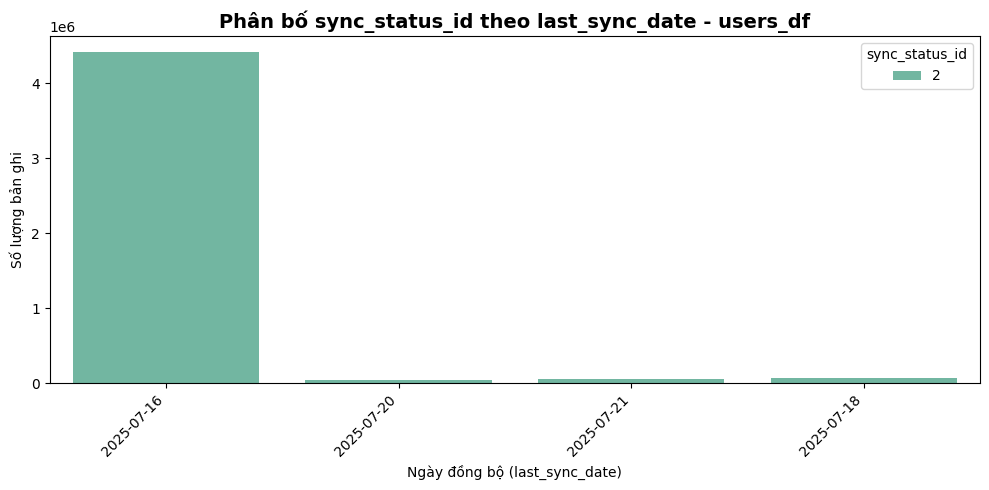


 Dataset: items_df

 Tỷ lệ % giá trị trong cột 'sync_status_id' của items_df:
sync_status_id
2    100.0

 Tỷ lệ % giá trị trong cột 'last_sync_date' của items_df:
last_sync_date
2025-07-18    99.97
2025-07-21     0.02
2025-07-20     0.01


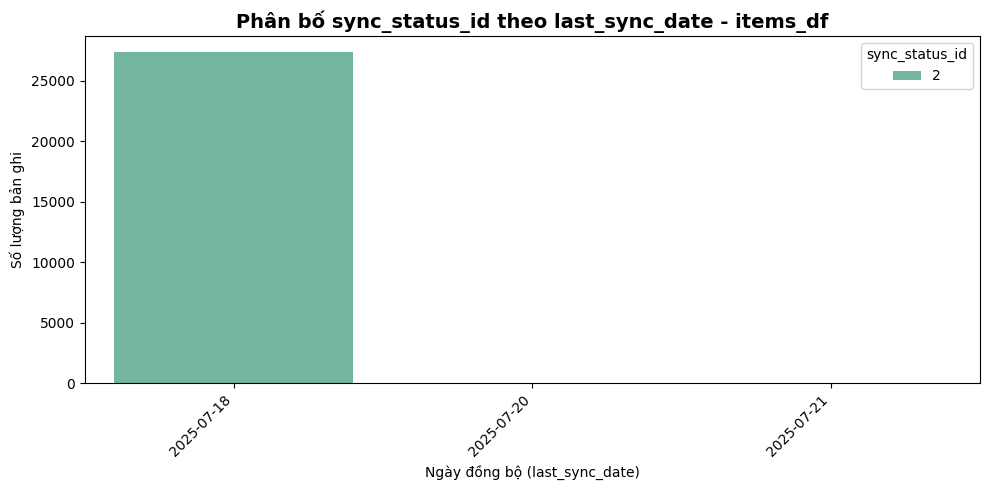

In [7]:
#Kiểm tra dữ liệu sau khi xử lí
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách dataset cần phân tích
datasets = [("users_df", users_df), ("items_df", items_df)]

for name, df in datasets:
    print(f"\n{'='*80}")
    print(f" Dataset: {name}")

    # Kiểm tra cột cần thiết
    required_cols = {'last_sync_date', 'sync_status_id'}
    if not required_cols.issubset(df.columns):
        print(f" Bỏ qua {name}: thiếu một trong các cột {required_cols}.")
        continue

    #  Nếu last_sync_date là string thì chuyển sang datetime
    if df['last_sync_date'].dtype == pl.Utf8:
        df = df.with_columns(
            pl.col("last_sync_date").str.to_datetime(strict=False)
        )

    # Chuyển sang pandas để thao tác và vẽ
    pdf = df.to_pandas()

    #  Chuẩn hóa dữ liệu ngày (chỉ lấy phần ngày)
    pdf['last_sync_date'] = pd.to_datetime(pdf['last_sync_date'], errors='coerce').dt.date

    #  Tính tỷ lệ % cho từng giá trị trong cột sync_status_id (bao gồm cả null)
    sync_percent = pdf['sync_status_id'].value_counts(normalize=True, dropna=False) * 100
    print(f"\n Tỷ lệ % giá trị trong cột 'sync_status_id' của {name}:")
    print(sync_percent.round(2).to_string())

    #  Tính tỷ lệ % cho từng ngày trong cột last_sync_date (bao gồm cả null)
    date_percent = pdf['last_sync_date'].value_counts(normalize=True, dropna=False) * 100
    print(f"\n Tỷ lệ % giá trị trong cột 'last_sync_date' của {name}:")
    print(date_percent.round(2).head(10).to_string())  # chỉ in 10 dòng đầu

    #  Vẽ biểu đồ phân bố sync_status_id theo ngày
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=pdf,
        x='last_sync_date',
        hue='sync_status_id',
        palette='Set2'
    )
    plt.title(f"Phân bố sync_status_id theo last_sync_date - {name}", fontsize=14, weight='bold')
    plt.xlabel("Ngày đồng bộ (last_sync_date)")
    plt.ylabel("Số lượng bản ghi")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
